### Prepare epochs

In [ ]:
import mne
from pathlib import Path
from mne import pick_types

mne.set_log_level(False)

tmin=0
tmax=4

# For both regression and ICA cleaning
all_epochs = {}
all_epochs["regr"] = []
all_epochs["ica"] = []

for method in ["regr", "ica"]:
    # Bandpass filter tu mu/beta band
    # (Most discriminatory signal in motor imagery is there)
    clean_filt_raws = []
    for subject in range(1, 10):
        raw = mne.io.read_raw_fif(Path("preproc", f"A0{subject}_{method}_raw.fif"), preload=True)
        filt_raw = raw.filter(l_freq=8, h_freq=30)

        # Epoch
        events, event_id = mne.events_from_annotations(filt_raw)
        picks = pick_types(filt_raw.info, meg=False, eeg=True, stim=False, eog=False, exclude="bads")
        epochs = mne.Epochs(filt_raw, events, event_id=event_id, picks=picks, tmin=tmin, tmax=tmax, baseline=None, preload=True, event_repeated='drop')

        all_epochs[method].append(epochs)

### Do within-ses training

In [2]:
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
from torch import nn
import pickle
import os
from datetime import datetime

from EEGNet import EEGNet, train

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for subject in range(9):
    epochs = all_epochs["regr"][subject]

    # Pick only the epochs leading up to the 4 class labels
    target_epochs = epochs[['769', '770', '771', '772']]

    X = target_epochs.get_data()
    X = X[:, np.newaxis, :, :] 

    y_raw = target_epochs.events[:, -1]
    y = LabelEncoder().fit_transform(y_raw)

    # Normalize per-trial or per-channel — z-score is standard
    X = (X - X.mean(axis=(2,3), keepdims=True)) / X.std(axis=(2,3), keepdims=True)

    X = torch.tensor(X, dtype=torch.float32).to(device)
    y = torch.tensor(y, dtype=torch.long).to(device)

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    train_ds = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

    val_ds = TensorDataset(X_val, y_val)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=True)

    model = EEGNet(n_classes=4, n_channels=X_train.shape[2], n_samples=X_train.shape[3])
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    n_epochs = 50
    patience = 5

    best_model, history = train(model, train_loader, val_loader, optimizer, criterion, n_epochs, patience, device, metrics=[accuracy_score, cohen_kappa_score])

    # Save the model
    save_path = 'models'

    # Create the directory if it doesn't exist
    os.makedirs(save_path, exist_ok=True)

    # Get current timestamp
    # timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    # Save the best_model's state dictionary
    model_save_path = os.path.join(save_path, f'subject_{subject+1}_best_eegnet_model.pth')
    torch.save(best_model.state_dict(), model_save_path)
    print(f"Best model saved to: {model_save_path}")

    # Save the training history
    history_save_path = os.path.join(save_path, f'subject_{subject+1}_eegnet_history.pkl')
    with open(history_save_path, 'wb') as f:
        pickle.dump(history, f)
    print(f"History saved to: {history_save_path}")
    



1 	 1.4014 	 1.3835 	 0.2696 	 0.2241
best val loss inf -> 1.3835
2 	 1.3694 	 1.3777 	 0.2913 	 0.2931
best val loss 1.3835 -> 1.3777
3 	 1.3415 	 1.3552 	 0.3522 	 0.4310
best val loss 1.3777 -> 1.3552
4 	 1.3157 	 1.3227 	 0.4000 	 0.5172
best val loss 1.3552 -> 1.3227
5 	 1.3009 	 1.2724 	 0.3826 	 0.5690
best val loss 1.3227 -> 1.2724
6 	 1.2431 	 1.2068 	 0.4217 	 0.6207
best val loss 1.2724 -> 1.2068
7 	 1.1858 	 1.1410 	 0.4739 	 0.5862
best val loss 1.2068 -> 1.1410
8 	 1.1294 	 1.0620 	 0.5043 	 0.5690
best val loss 1.1410 -> 1.0620
9 	 1.0521 	 1.0024 	 0.5739 	 0.5690
best val loss 1.0620 -> 1.0024
10 	 0.9716 	 0.9316 	 0.6652 	 0.6207
best val loss 1.0024 -> 0.9316
11 	 0.9308 	 0.8930 	 0.5957 	 0.6207
best val loss 0.9316 -> 0.8930
12 	 0.9159 	 0.8883 	 0.6261 	 0.6207
best val loss 0.8930 -> 0.8883
13 	 0.9138 	 0.8703 	 0.6304 	 0.6379
best val loss 0.8883 -> 0.8703
14 	 0.8181 	 0.8345 	 0.6652 	 0.6379
best val loss 0.8703 -> 0.8345
15 	 0.7886 	 0.8218 	 0.6565 	 

In [3]:
inses_accs_dict = {}
inses_kappas_dict = {}

for f in os.listdir('models'):
    if 'history' in f:
        subject = f.split('_')[1]
        with open(Path('models', f), "rb") as ff:
            history = pickle.load(ff)
            best_loss = np.inf
            best_acc = 0
            best_kappa = 0
            for dict in history:
                if dict['valid_loss'] < best_loss:
                    best_loss = dict['valid_loss']
                    best_acc = dict['valid_perf'][0]
                    best_kappa = dict['valid_perf'][1]
        inses_accs_dict[subject] = best_acc
        inses_kappas_dict[subject] = best_kappa

inses_accs = []
inses_kappas = []
for i in range(1, 10):
    inses_accs.append(inses_accs_dict[str(i)])
    inses_kappas.append(inses_kappas_dict[str(i)])
inses_accs, inses_kappas

([0.6379310344827587,
  0.3103448275862069,
  0.7931034482758621,
  0.3793103448275862,
  0.1724137931034483,
  0.27586206896551724,
  0.22413793103448276,
  0.8448275862068966,
  0.8448275862068966],
 [0.5024509803921569,
  0.09233176838810642,
  0.7170731707317073,
  0.16513394642143142,
  -0.06544202066590121,
  0.06595092024539895,
  -0.04108496210610313,
  0.7908653846153846,
  0.7900241351568785])

### Validate on out-of-ses data

In [4]:
from mne.preprocessing import EOGRegression
from scipy.io import loadmat

datadir = "BCICIV_2a_gdf"

outses_accs = []
outses_kappas = []

for subject in range(1, 10):
    model_save_path = os.path.join(save_path, f'subject_{subject}_best_eegnet_model.pth')
    model = EEGNet(n_classes=4, n_channels=22, n_samples=1001)
    model.load_state_dict(torch.load(f=model_save_path))

    # Load test session
    raw = mne.io.read_raw_gdf(Path(datadir, f"A0{subject}E.gdf"), preload=True)

    # Test session preprocessing
    # Mark the EOG channels
    raw.set_channel_types({'EOG-left': 'eog', 'EOG-central': 'eog', 'EOG-right': 'eog'})

    # Reference using CAR
    ref_raw = mne.set_eeg_reference(raw, 'average', projection=False)[0]

    # Remove slow drifts from the signal
    filt_raw = ref_raw.filter(l_freq=1, h_freq=None)

    # EOG Regression
    weights = EOGRegression(picks="eeg", picks_artifact="eog").fit(filt_raw)
    regr_raw = weights.apply(filt_raw, copy=True)

    # Bandpass filter to mu/beta band
    mubeta_raw = regr_raw.filter(l_freq=8, h_freq=30)

    # Epoch
    events, event_id = mne.events_from_annotations(mubeta_raw)
    picks = pick_types(mubeta_raw.info, meg=False, eeg=True, stim=False, eog=False, exclude="bads")
    epochs = mne.Epochs(mubeta_raw, events, event_id=event_id, picks=picks, tmin=tmin+2, tmax=tmax+2, baseline=None, preload=True, event_repeated='drop')
    trial_epochs = epochs[['768']]

    # Get data and labels
    X = trial_epochs.get_data()
    X = X[:, np.newaxis, :, :]
    X = (X - X.mean(axis=(2,3), keepdims=True)) / X.std(axis=(2,3), keepdims=True)
    X = torch.tensor(X, dtype=torch.float32).to(device)

    # Get true labels
    y_true = LabelEncoder().fit_transform(loadmat(Path(datadir, 'true_labels', f'A0{subject}E.mat'))['classlabel'].flatten())
    
    y_pred = torch.argmax(model(X), axis=1)

    outses_accs.append(accuracy_score(y_true, y_pred))
    outses_kappas.append(cohen_kappa_score(y_true, y_pred))

/home/david-daubner/Apps/miniconda3/envs/eeg-torch/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/david-daubner/Apps/miniconda3/envs/eeg-torch/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/david-daubner/Apps/miniconda3/envs/eeg-torch/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/david-daubner/Apps/miniconda3/envs/eeg-torch/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/david-daubner/Apps/miniconda3/envs/eeg-torch/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are n

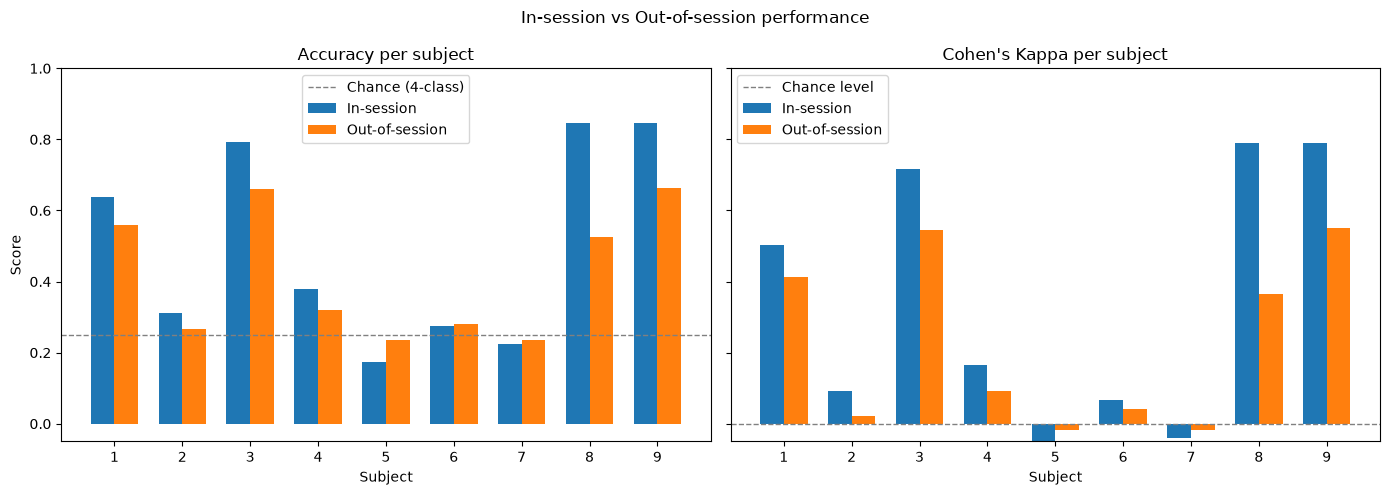

In [5]:
import matplotlib.pyplot as plt

n = len(inses_accs)
x = np.arange(n)
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
 
# --- Accuracy subplot ---
ax = axes[0]
ax.bar(x - width/2, inses_accs, width, label="In-session")
ax.bar(x + width/2, outses_accs, width, label="Out-of-session")
ax.set_title("Accuracy per subject")
ax.set_xlabel("Subject")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(list(range(1, 10)))
ax.axhline(0.25, color="gray", linestyle="--", linewidth=1, label="Chance (4-class)")
ax.legend()
ax.set_ylim(0, 1)
 
# --- Kappa subplot ---
ax = axes[1]
ax.bar(x - width/2, inses_kappas, width, label="In-session")
ax.bar(x + width/2, outses_kappas, width, label="Out-of-session")
ax.set_title("Cohen's Kappa per subject")
ax.set_xlabel("Subject")
ax.set_xticks(x)
ax.set_xticklabels(list(range(1, 10)))
ax.axhline(0.0, color="gray", linestyle="--", linewidth=1, label="Chance level")
ax.legend()
ax.set_ylim(-0.05, 1)
 
fig.suptitle("In-session vs Out-of-session performance")
fig.tight_layout()
# fig.savefig("subject_scores.png", dpi=150)
plt.show()

### Train on all subjects

In [6]:
all_X_train, all_X_val, all_y_train, all_y_val = [], [], [], []

for subject in range(9):
    epochs = all_epochs["regr"][subject]

    # Pick only the epochs leading up to the 4 class labels
    target_epochs = epochs[['769', '770', '771', '772']]

    X = target_epochs.get_data()
    X = X[:, np.newaxis, :, :]
    X = (X - X.mean(axis=(2,3), keepdims=True)) / X.std(axis=(2,3), keepdims=True)

    y_raw = target_epochs.events[:, -1]
    y = LabelEncoder().fit_transform(y_raw)

    # Normalize per-trial or per-channel — z-score is standard
    X = (X - X.mean(axis=(2,3), keepdims=True)) / X.std(axis=(2,3), keepdims=True)

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

    all_X_train.append(X_train)
    all_X_val.append(X_val)
    all_y_train.append(y_train)
    all_y_val.append(y_val)

X_train = np.concatenate(all_X_train, axis=0)
X_val = np.concatenate(all_X_val, axis=0)
y_train = np.concatenate(all_y_train, axis=0)
y_val = np.concatenate(all_y_val, axis=0)

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.long).to(device)
X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
y_val = torch.tensor(y_val, dtype=torch.long).to(device)

train_ds = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

val_ds = TensorDataset(X_val, y_val)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=True)

model = EEGNet(n_classes=4, n_channels=X_train.shape[2], n_samples=X_train.shape[3])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

n_epochs = 50
patience = 5

best_model, history = train(model, train_loader, val_loader, optimizer, criterion, n_epochs, patience, device, metrics=[accuracy_score, cohen_kappa_score])

# Save the model
save_path = 'models'

# Create the directory if it doesn't exist
os.makedirs(save_path, exist_ok=True)

# Get current timestamp
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save the best_model's state dictionary
model_save_path = os.path.join(save_path, f'all_subjects_best_eegnet_model.pth')
torch.save(best_model.state_dict(), model_save_path)
print(f"Best model saved to: {model_save_path}")

# Save the training history
history_save_path = os.path.join(save_path, f'all_subjects_eegnet_history.pkl')
with open(history_save_path, 'wb') as f:
    pickle.dump(history, f)
print(f"History saved to: {history_save_path}")

1 	 1.3911 	 1.3839 	 0.2628 	 0.2395
best val loss inf -> 1.3839
2 	 1.3667 	 1.3496 	 0.3082 	 0.3429
best val loss 1.3839 -> 1.3496
3 	 1.3382 	 1.2874 	 0.3498 	 0.4138
best val loss 1.3496 -> 1.2874
4 	 1.2798 	 1.2071 	 0.3961 	 0.5038
best val loss 1.2874 -> 1.2071
5 	 1.2269 	 1.1441 	 0.4217 	 0.5000
best val loss 1.2071 -> 1.1441
6 	 1.1929 	 1.0991 	 0.4469 	 0.5268
best val loss 1.1441 -> 1.0991
7 	 1.1687 	 1.0966 	 0.4705 	 0.5517
best val loss 1.0991 -> 1.0966
8 	 1.1755 	 1.0940 	 0.4647 	 0.5345
best val loss 1.0966 -> 1.0940
9 	 1.1468 	 1.0944 	 0.4826 	 0.5326
10 	 1.1478 	 1.0886 	 0.4874 	 0.5479
best val loss 1.0940 -> 1.0886
11 	 1.1281 	 1.0547 	 0.4937 	 0.5690
best val loss 1.0886 -> 1.0547
12 	 1.1338 	 1.0825 	 0.4802 	 0.5307
13 	 1.0976 	 1.0597 	 0.5155 	 0.5632
14 	 1.1032 	 1.0677 	 0.4971 	 0.5536
15 	 1.1031 	 1.0432 	 0.4966 	 0.5632
best val loss 1.0547 -> 1.0432
16 	 1.0930 	 1.0384 	 0.5184 	 0.5670
best val loss 1.0432 -> 1.0384
17 	 1.0696 	 1.

In [ ]:
import os
from EEGNet import EEGNet
import numpy as np
import torch
from sklearn.metrics import cohen_kappa_score, accuracy_score
from sklearn.preprocessing import LabelEncoder
import mne
from mne.preprocessing import EOGRegression
from pathlib import Path
from scipy.io import loadmat

datadir = 'BCICIV_2a_gdf'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


inses_accs = []
inses_kappas = []
outses_accs = []
outses_kappas = []

X_test = []
y_test = []

X_train = []
y_train = []

model_save_path = os.path.join('models', f'all_subjects_best_eegnet_model.pth')
model = EEGNet(n_classes=4, n_channels=22, n_samples=1001)
model.load_state_dict(torch.load(f=model_save_path))
model.eval()

for subject in range(1, 10):
    epochs = all_epochs["regr"][subject-1]
    
    # Pick only the epochs leading up to the 4 class labels
    target_epochs = epochs[['769', '770', '771', '772']]

    X = target_epochs.get_data()
    X = X[:, np.newaxis, :, :] 
    X = (X - X.mean(axis=(2,3), keepdims=True)) / X.std(axis=(2,3), keepdims=True)
    X = torch.tensor(X, dtype=torch.float32).to(device)

    y_raw = target_epochs.events[:, -1]
    y = LabelEncoder().fit_transform(y_raw)
    y = torch.tensor(y, dtype=torch.long).to(device)
    
    y_pred = torch.argmax(model(X), axis=1)

    inses_accs.append(accuracy_score(y, y_pred))
    inses_kappas.append(cohen_kappa_score(y, y_pred))

    X_train.append(X)
    y_train.append(y)


    # Load test session
    raw = mne.io.read_raw_gdf(Path(datadir, f"A0{subject}E.gdf"), preload=True)

    # Test session preprocessing
    # Mark the EOG channels
    raw.set_channel_types({'EOG-left': 'eog', 'EOG-central': 'eog', 'EOG-right': 'eog'});

    # Reference using CAR
    ref_raw = mne.set_eeg_reference(raw, 'average', projection=False)[0];

    # Remove slow drifts from the signal
    filt_raw = ref_raw.filter(l_freq=1, h_freq=None);

    # EOG Regression
    weights = EOGRegression(picks="eeg", picks_artifact="eog").fit(filt_raw);
    regr_raw = weights.apply(filt_raw, copy=True)

    # Bandpass filter to mu/beta band
    mubeta_raw = regr_raw.filter(l_freq=8, h_freq=30);

    # Epoch
    events, event_id = mne.events_from_annotations(mubeta_raw)
    picks = pick_types(mubeta_raw.info, meg=False, eeg=True, stim=False, eog=False, exclude="bads")
    epochs = mne.Epochs(mubeta_raw, events, event_id=event_id, picks=picks, tmin=tmin+2, tmax=tmax+2, baseline=None, preload=True, event_repeated='drop');
    trial_epochs = epochs[['768']]

    # Get data and labels
    X = trial_epochs.get_data()
    X = X[:, np.newaxis, :, :] 
    X = (X - X.mean(axis=(2,3), keepdims=True)) / X.std(axis=(2,3), keepdims=True)
    X = torch.tensor(X, dtype=torch.float32).to(device)

    # Get true labels
    y_true = LabelEncoder().fit_transform(loadmat(Path(datadir, 'true_labels', f'A0{subject}E.mat'))['classlabel'].flatten())
    
    y_pred = torch.argmax(model(X), axis=1)

    outses_accs.append(accuracy_score(y_true, y_pred))
    outses_kappas.append(cohen_kappa_score(y_true, y_pred))

    X_test.append(X)
    y_test.append(y)

X_test = np.concatenate(X_test, axis=0)
y_test = np.concatenate(y_test, axis=0)

X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.long).to(device)

y_pred_test = torch.argmax(model(X_test), axis=1)

X_train = np.concatenate(X_train, axis=0)
y_train = np.concatenate(y_train, axis=0)

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.long).to(device)

y_pred_train = torch.argmax(model(X_train), axis=1)

print(f"In-ses global accuracy = {accuracy_score(y_pred_train, y_train)}, global kappa = {cohen_kappa_score(y_pred_train, y_train)}")
print(f"Out-of-ses global accuracy = {accuracy_score(y_pred_test, y_test)}, global kappa = {cohen_kappa_score(y_pred_test, y_test)}")

os.makedirs('results', exist_ok=True)

np.savetxt(Path('results', 'eegnet_inses_accs_regr.csv'), inses_accs, delimiter=',')
np.savetxt(Path('results', 'eegnet_inses_kappas_regr.csv'), inses_kappas, delimiter=',')
np.savetxt(Path('results', 'eegnet_outses_accs.csv'), outses_accs, delimiter=',')
np.savetxt(Path('results', 'eegnet_outses_kappas.csv'), outses_kappas, delimiter=',')

/home/david-daubner/Apps/miniconda3/envs/eeg-torch/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/david-daubner/Apps/miniconda3/envs/eeg-torch/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/david-daubner/Apps/miniconda3/envs/eeg-torch/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/david-daubner/Apps/miniconda3/envs/eeg-torch/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)
/home/david-daubner/Apps/miniconda3/envs/eeg-torch/lib/python3.14/contextlib.py:148: RuntimeWarning: Channel names are n

In-ses global accuracy = 0.6138117283950617, global kappa = 0.48508230452674894
Out-of-ses global accuracy = 0.39699074074074076, global kappa = 0.19598765432098764


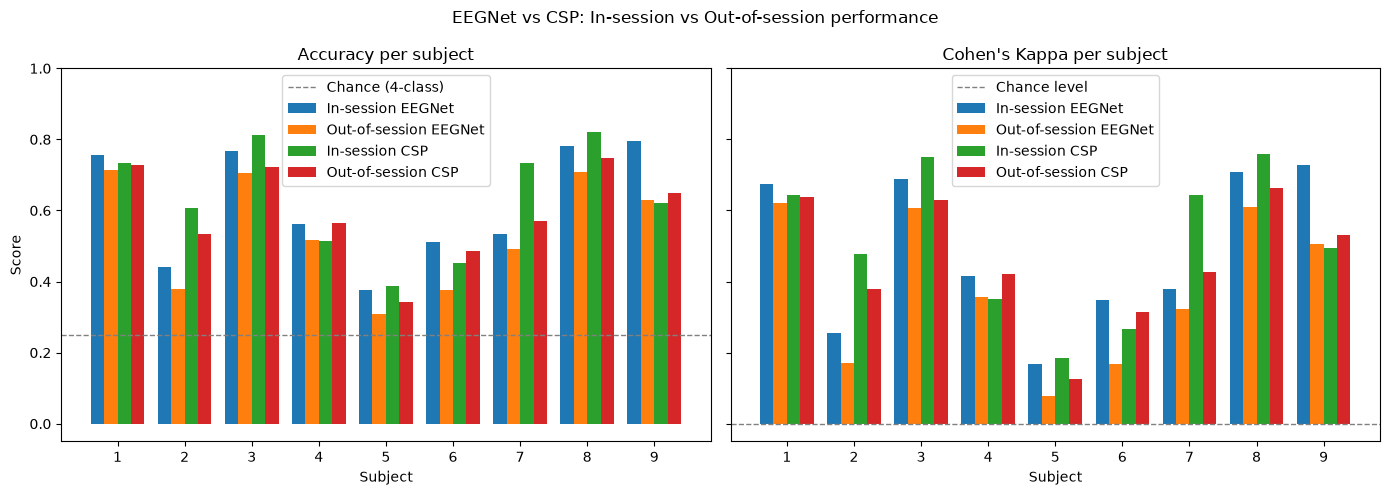

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

csp_inses_accs = np.loadtxt(Path('results', 'csp_inses_accs_regr.csv'), delimiter=',')
csp_outses_accs = np.loadtxt(Path('results', 'csp_outses_accs.csv'), delimiter=',')
csp_inses_kappas = np.loadtxt(Path('results', 'csp_inses_kappas_regr.csv'), delimiter=',')
csp_outses_kappas = np.loadtxt(Path('results', 'csp_outses_kappas.csv'), delimiter=',')

inses_accs = np.loadtxt(Path('results', 'eegnet_inses_accs_regr.csv'), delimiter=',')
outses_accs = np.loadtxt(Path('results', 'eegnet_outses_accs.csv'), delimiter=',')
inses_kappas = np.loadtxt(Path('results', 'eegnet_inses_kappas_regr.csv'), delimiter=',')
outses_kappas = np.loadtxt(Path('results', 'eegnet_outses_kappas.csv'), delimiter=',')

n = len(inses_accs)
x = np.arange(n)
width = 0.2  # narrower to fit 4 bars per subject

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# --- Accuracy subplot ---
ax = axes[0]
ax.bar(x - 1.5*width, inses_accs, width, label="In-session EEGNet")
ax.bar(x - 0.5*width, outses_accs, width, label="Out-of-session EEGNet")
ax.bar(x + 0.5*width, csp_inses_accs, width, label="In-session CSP")
ax.bar(x + 1.5*width, csp_outses_accs, width, label="Out-of-session CSP")
ax.set_title("Accuracy per subject")
ax.set_xlabel("Subject")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(list(range(1, 10)))
ax.axhline(0.25, color="gray", linestyle="--", linewidth=1, label="Chance (4-class)")
ax.legend()
ax.set_ylim(0, 1)

# --- Kappa subplot ---
ax = axes[1]
ax.bar(x - 1.5*width, inses_kappas, width, label="In-session EEGNet")
ax.bar(x - 0.5*width, outses_kappas, width, label="Out-of-session EEGNet")
ax.bar(x + 0.5*width, csp_inses_kappas, width, label="In-session CSP")
ax.bar(x + 1.5*width, csp_outses_kappas, width, label="Out-of-session CSP")
ax.set_title("Cohen's Kappa per subject")
ax.set_xlabel("Subject")
ax.set_xticks(x)
ax.set_xticklabels(list(range(1, 10)))
ax.axhline(0.0, color="gray", linestyle="--", linewidth=1, label="Chance level")
ax.legend()
ax.set_ylim(-0.05, 1)

fig.suptitle("EEGNet vs CSP: In-session vs Out-of-session performance")
fig.tight_layout()
# fig.savefig("subject_scores.png", dpi=150)
plt.show()